In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import krippendorff as kd
from sklearn.metrics import accuracy_score


In [85]:
from matplotlib import rcParams


rcParams['font.family'] = 'STIXGeneral'
rcParams['font.size'] = 12  # Optional: adjust to match Overleaf's text size

rcParams.update({
    "font.size": 12,       
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300
    }
)

FIG_WIDTH = 9.33
FIG_HEIGHT = 7 * 0.66  
FIGSIZE_HORIZONTAL = (FIG_WIDTH, FIG_HEIGHT)

rcParams['figure.figsize'] = FIGSIZE_HORIZONTAL  


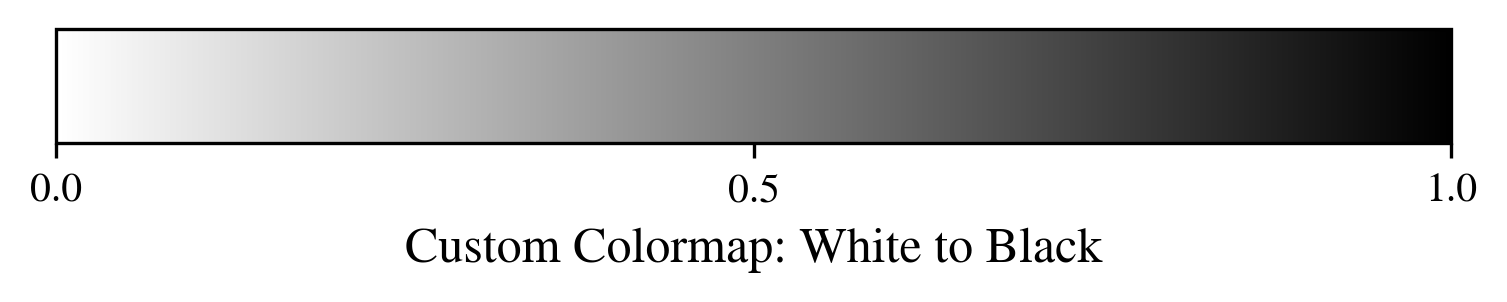

In [86]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.cm as cm


seq_cm = LinearSegmentedColormap.from_list('custom_blues', ['white', 'Black'])

fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)
norm = mcolors.Normalize(vmin=0, vmax=1)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=seq_cm), cax=ax, orientation='horizontal')
cb.set_label('Custom Colormap: White to Black')
cb.set_ticks([0, 0.5, 1])
plt.show()

In [87]:
labels = pd.read_csv('EDA/data/lans_all_labels.csv')
cons = labels[["block_id", "dx"]]
cons = cons[["block_id", "dx"]].replace({1: 0, 2: np.nan, 3: 1, 4: 2})
cons = cons.dropna(subset=["dx"])

In [88]:
rater_labels = labels.loc[:,"p53":]
rater_labels = rater_labels.drop(["p53"], axis=1).replace({1: 0, 2: np.nan, 3: 1, 4: 2, 0 : 3})
rater_labels = pd.concat([labels["block_id"], rater_labels], axis=1)

In [89]:
basis = {}
results = []
acc_individual = []
acc_consensus = []
difference = []

for path in range(1, 21):
    for fold in range(1, 6):
        df = pd.read_csv(f'/data/archief/AMC-data/Barrett/experiments/jans_experiments/final_intra_Pathologist_{path}_fold_{fold}/results.csv').sort_values(by="block_id")
        basis[(path, fold, "df")] = df
        basis[(path, fold, "individual_labels")] = df["label"]
        basis[(path, fold, "predictions")] = df["pred_class"]
        basis[(path, fold, "consensus_labels")] = cons[cons["block_id"].isin(df["block_id"])]["dx"]

        results.append({
            "path": path,
            "fold": fold,
            "accuracy_individual": accuracy_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")]
            ),
            "accuracy_consensus": accuracy_score(
                basis[(path, fold, "consensus_labels")],
                basis[(path, fold, "predictions")]
            ),
            "difference": accuracy_score(
                basis[(path, fold, "consensus_labels")],
                basis[(path, fold, "predictions")]
            ) - accuracy_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")]
            ),
            "samples": len(df)
        })
results1 = pd.DataFrame(results)


In [90]:
from sklearn.metrics import f1_score


basis = {}
results = []
acc_individual = []
acc_consensus = []
difference = []

for path in range(1, 21):
    for fold in range(1, 6):
        df = pd.read_csv(f'/data/archief/AMC-data/Barrett/experiments/jans_experiments/final_intra_Pathologist_{path}_fold_{fold}/results.csv').sort_values(by="block_id")
        basis[(path, fold, "df")] = df
        basis[(path, fold, "individual_labels")] = df["label"]
        basis[(path, fold, "predictions")] = df["pred_class"]
        basis[(path, fold, "consensus_labels")] = cons[cons["block_id"].isin(df["block_id"])]["dx"]

        results.append({
            "path": path,
            "fold": fold,
            "accuracy_individual": f1_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")],
                average='macro'
            ),
            "accuracy_consensus": f1_score(
                basis[(path, fold, "consensus_labels")],
                basis[(path, fold, "predictions")],
                average='macro'
            ),
            "difference": f1_score(
                basis[(path, fold, "consensus_labels")],
                basis[(path, fold, "predictions")],
                average='macro'
            ) - f1_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")],
                average='macro'
            ),
            "samples": len(df)
        })
results2 = pd.DataFrame(results)


In [91]:
results_agg1 = pd.DataFrame()
results_agg1[["mean_acc_ind", "mean_acc_cons", "diff_means"]] = results1.groupby(["path"])[["accuracy_individual", "accuracy_consensus", "difference"]].mean()
results_agg1["min_ind"] = results1.groupby(["path"])[["accuracy_individual"]].min()
results_agg1["max_ind"] = results1.groupby(["path"])[["accuracy_individual"]].max()
results_agg1["min_cons"] = results1.groupby(["path"])[["accuracy_consensus"]].min()
results_agg1["max_cons"] = results1.groupby(["path"])[["accuracy_consensus"]].max()
results_agg1["samples"] = results1.groupby(["path"])[["samples"]].sum()

In [92]:
results_agg2 = pd.DataFrame()
results_agg2[["mean_acc_ind", "mean_acc_cons", "diff_means"]] = results2.groupby(["path"])[["accuracy_individual", "accuracy_consensus", "difference"]].mean()
results_agg2["min_ind"] = results2.groupby(["path"])[["accuracy_individual"]].min()
results_agg2["max_ind"] = results2.groupby(["path"])[["accuracy_individual"]].max()
results_agg2["min_cons"] = results2.groupby(["path"])[["accuracy_consensus"]].min()
results_agg2["max_cons"] = results2.groupby(["path"])[["accuracy_consensus"]].max()
results_agg2["samples"] = results2.groupby(["path"])[["samples"]].sum()

In [93]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
results_agg1["normalized_difference"] = scaler.fit_transform(np.array(results_agg1["diff_means"]).reshape(-1, 1))
scaler = MinMaxScaler(feature_range=(0, 1))
results_agg2["normalized_difference"] = scaler.fit_transform(np.array(results_agg2["diff_means"]).reshape(-1, 1))



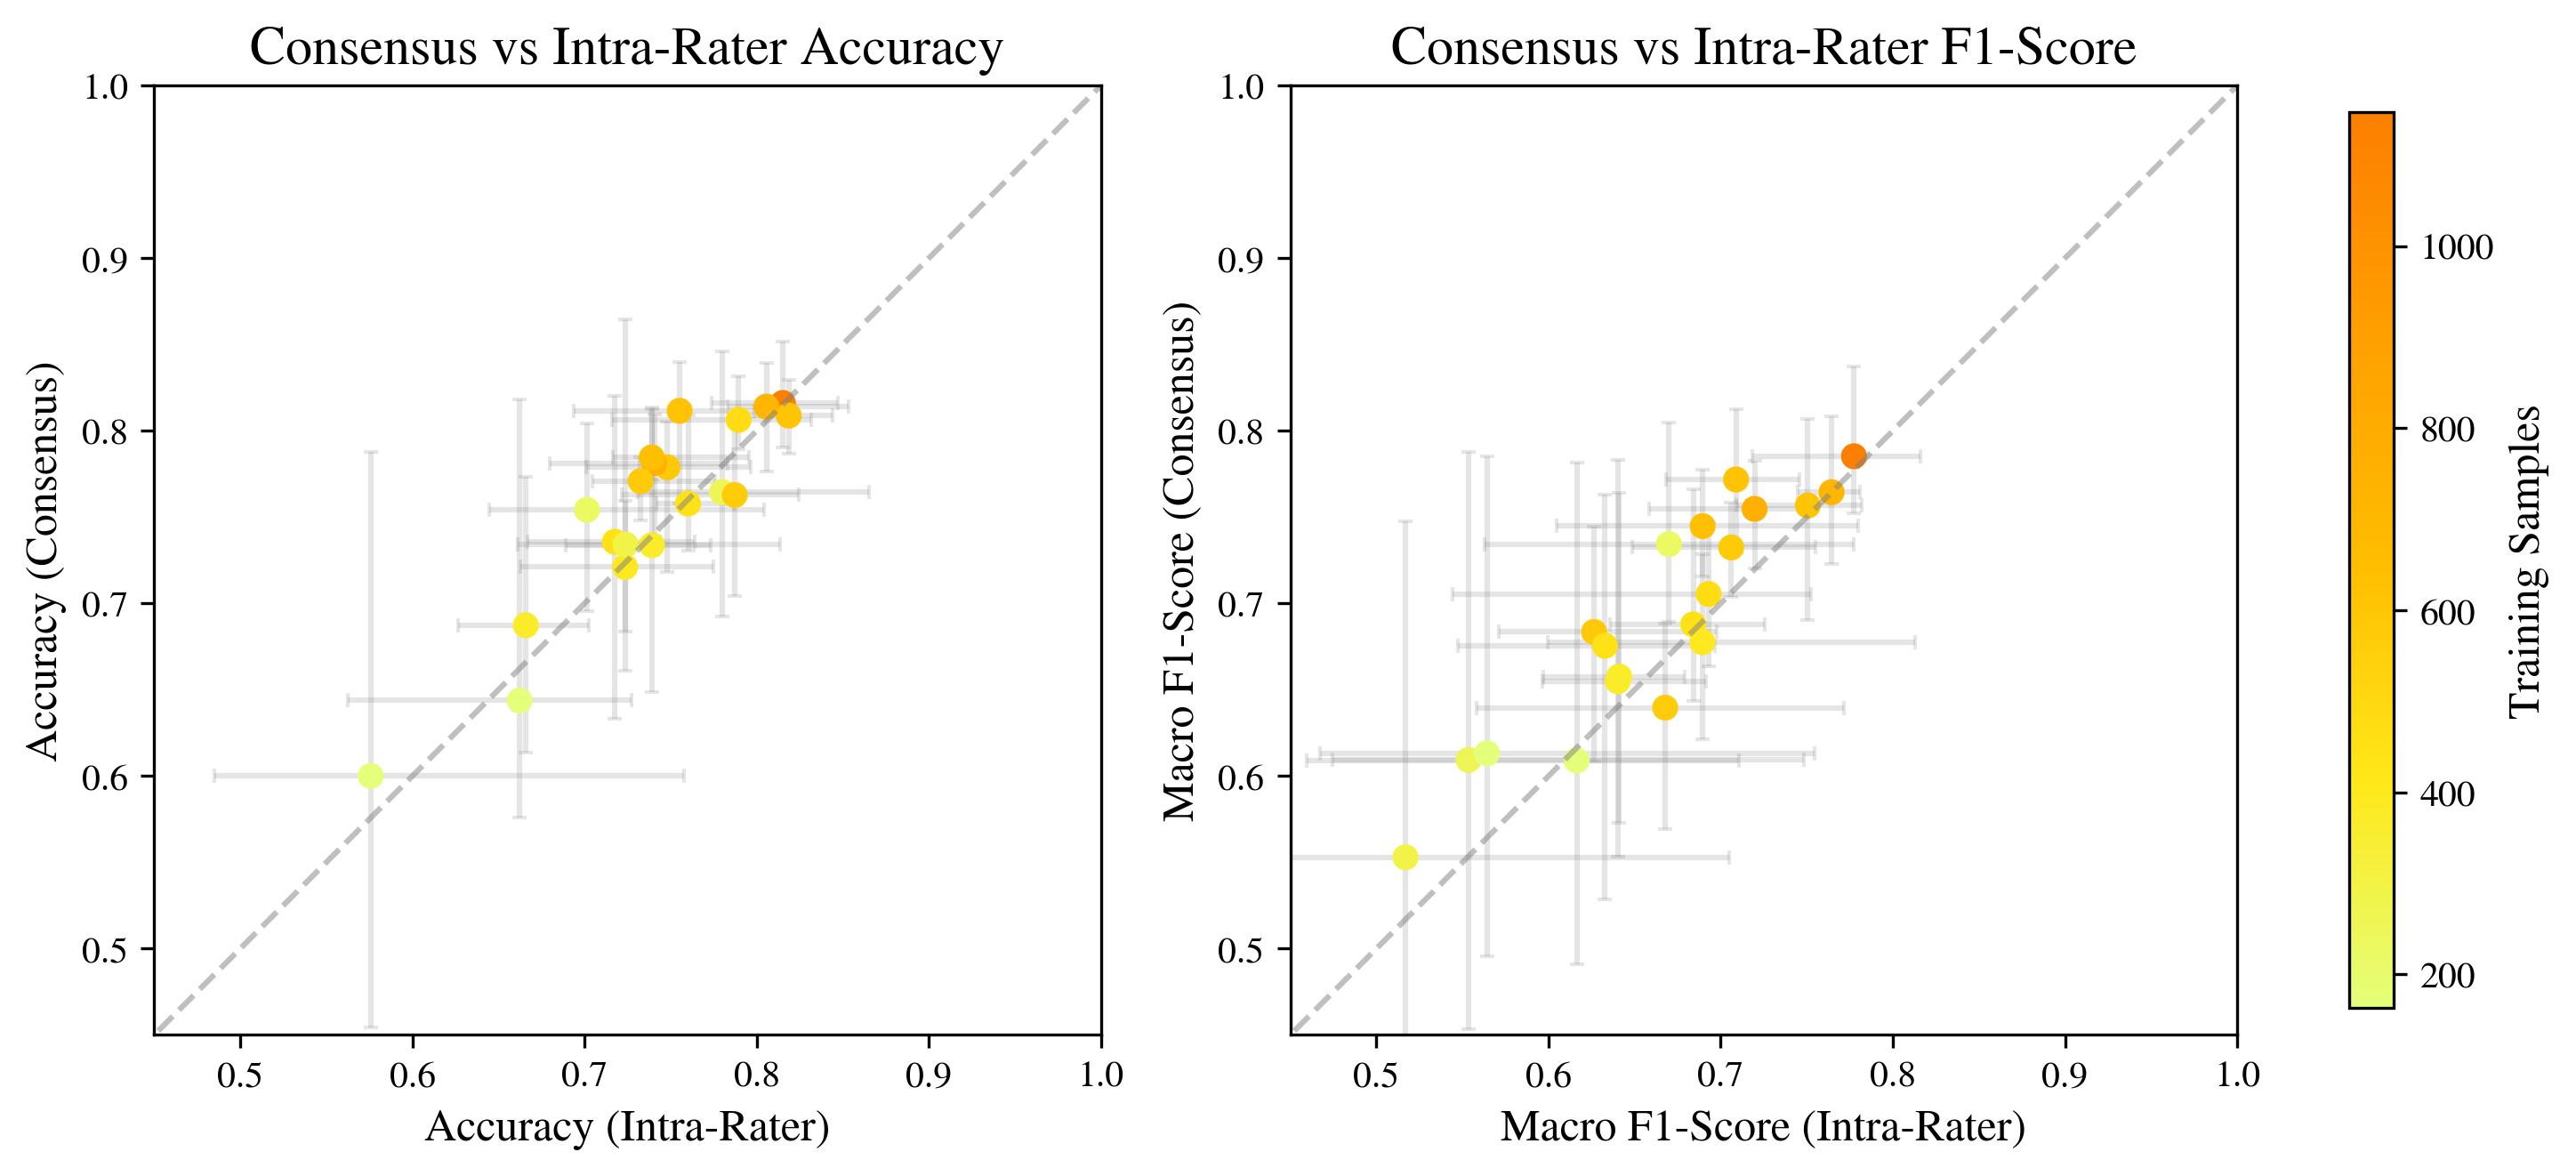

In [115]:
fig, axs = plt.subplots(1, 2, figsize=(FIG_WIDTH + 1.5, FIG_HEIGHT))  # Increased width for colorbar

# First subplot
sc1 = axs[0].scatter(results_agg1["mean_acc_ind"], results_agg1["mean_acc_cons"], c=results_agg1["samples"], cmap='Wistia', zorder=1)
axs[0].errorbar(results_agg1["mean_acc_ind"], results_agg1["mean_acc_cons"], 
                xerr=[results_agg1["mean_acc_ind"] - results_agg1["min_ind"], results_agg1["max_ind"] - results_agg1["mean_acc_ind"]], 
                yerr=[results_agg1["mean_acc_cons"] - results_agg1["min_cons"], results_agg1["max_cons"] - results_agg1["mean_acc_cons"]], 
                fmt=" ", ecolor="grey", capsize=2, alpha=0.2, zorder=0)
axs[0].set_xlabel("Accuracy (Intra-Rater)")
axs[0].set_ylabel("Accuracy (Consensus)")
axs[0].set_ylim(0.45, 1)
axs[0].set_xlim(0.45, 1)
axs[0].set_title("Consensus vs Intra-Rater Accuracy")
axs[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)

# Second subplot
sc2 = axs[1].scatter(results_agg2["mean_acc_ind"], results_agg2["mean_acc_cons"], c=results_agg2["samples"], cmap='Wistia', zorder=1)
axs[1].errorbar(results_agg2["mean_acc_ind"], results_agg2["mean_acc_cons"], 
                xerr=[results_agg2["mean_acc_ind"] - results_agg2["min_ind"], results_agg2["max_ind"] - results_agg2["mean_acc_ind"]], 
                yerr=[results_agg2["mean_acc_cons"] - results_agg2["min_cons"], results_agg2["max_cons"] - results_agg2["mean_acc_cons"]], 
                fmt=" ", ecolor="grey", capsize=2, alpha=0.2, zorder=0)
axs[1].set_xlabel("Macro F1-Score (Intra-Rater)")
axs[1].set_ylabel("Macro F1-Score (Consensus)")
axs[1].set_ylim(0.45, 1)
axs[1].set_xlim(0.45, 1)
axs[1].set_title("Consensus vs Intra-Rater F1-Score")
axs[1].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)

# Add a single colorbar for both plots
cbar = fig.colorbar(sc1, ax=axs, orientation='vertical', fraction=0.02, pad=0.05) 
cbar.set_label('Training Samples')

# plt.tight_layout(pad=2.0) 
plt.show()
fig.subplots_adjust(hspace=0.4, wspace=0.4)  # Adjust spacing between subplots


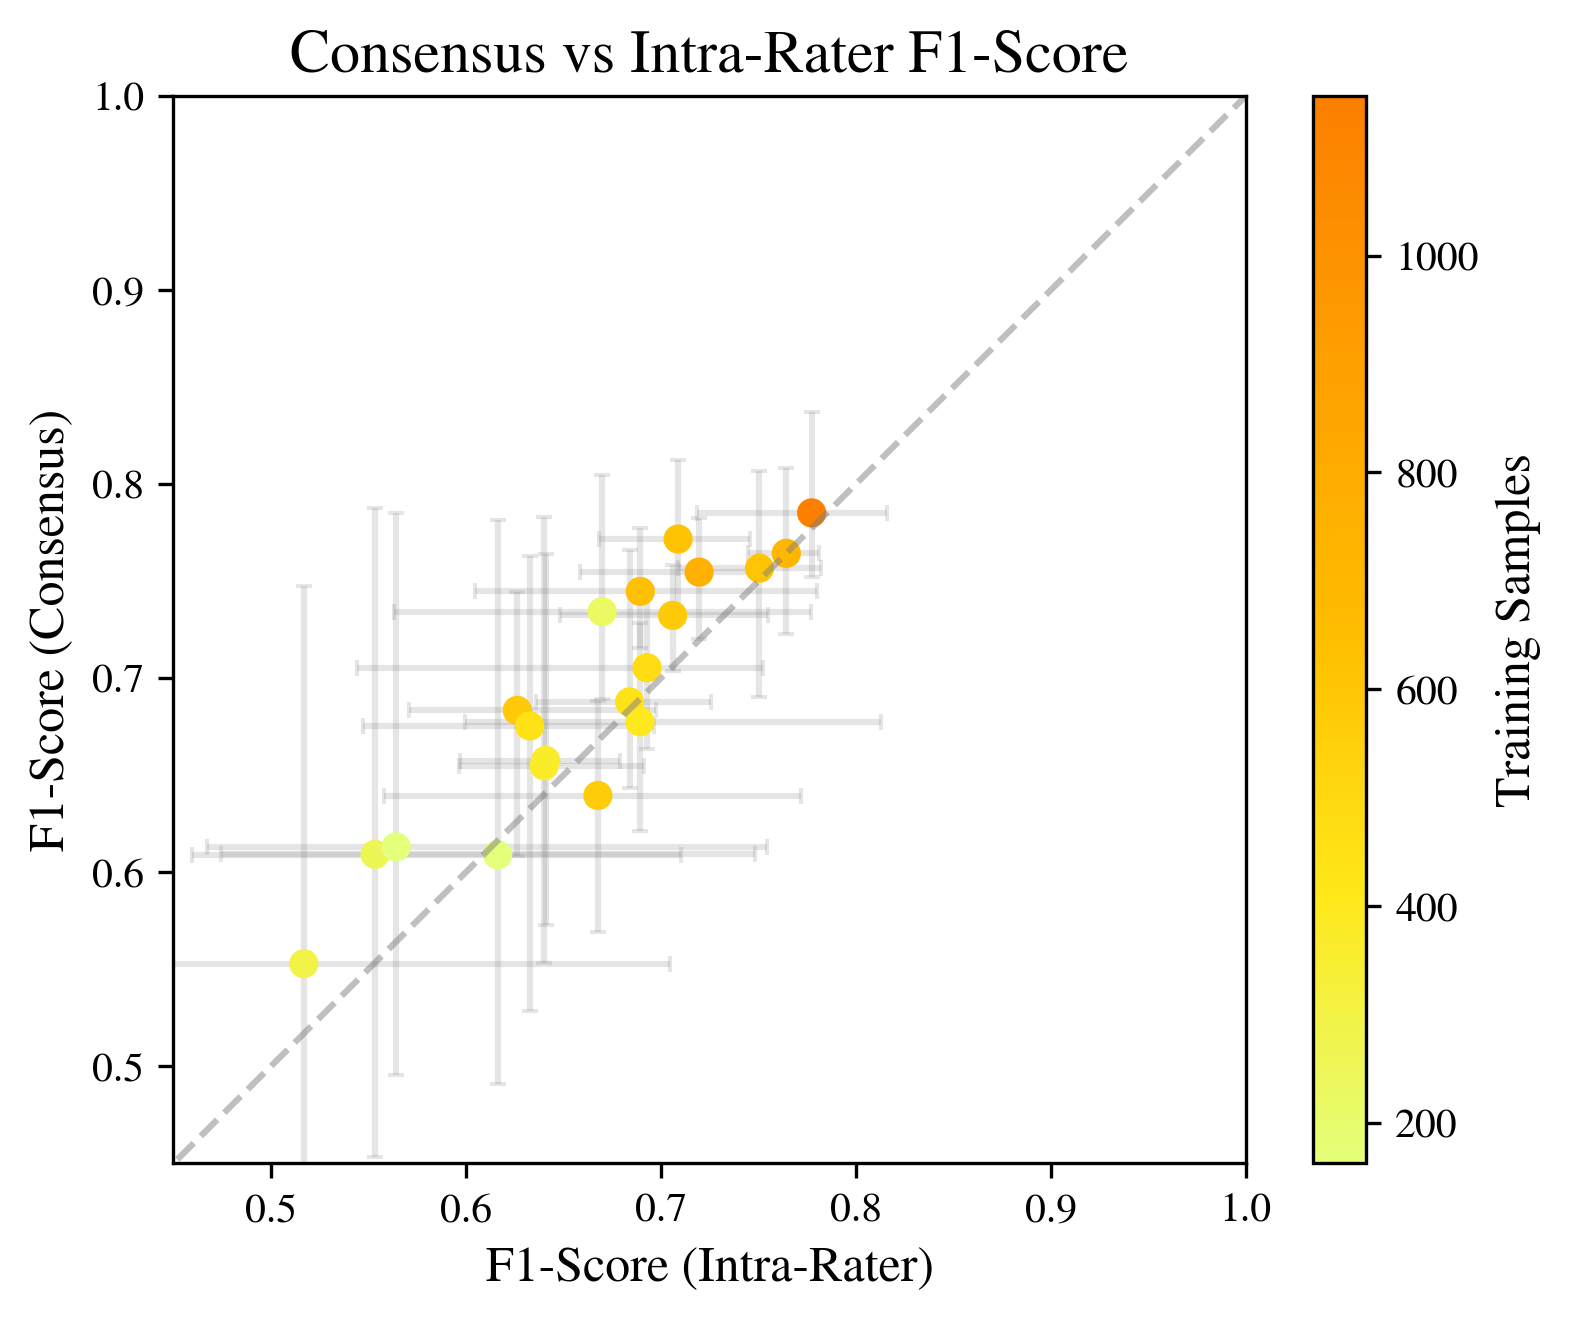

In [124]:
fig, axs = plt.subplots(1, 1, figsize=(FIG_WIDTH / 2 + 1.1, FIG_HEIGHT))  # Adjusted to only one subplot

# First subplot
sc1 = axs.scatter(results_agg2["mean_acc_ind"], results_agg2["mean_acc_cons"], c=results_agg2["samples"], cmap='Wistia', zorder=1)
axs.errorbar(results_agg2["mean_acc_ind"], results_agg2["mean_acc_cons"], 
              xerr=[results_agg2["mean_acc_ind"] - results_agg2["min_ind"], results_agg2["max_ind"] - results_agg2["mean_acc_ind"]], 
              yerr=[results_agg2["mean_acc_cons"] - results_agg2["min_cons"], results_agg2["max_cons"] - results_agg2["mean_acc_cons"]], 
              fmt=" ", ecolor="grey", capsize=2, alpha=0.2, zorder=0)
axs.set_xlabel("F1-Score (Intra-Rater)")
axs.set_ylabel("F1-Score (Consensus)")
axs.set_ylim(0.45, 1)
axs.set_xlim(0.45, 1)
axs.set_title("Consensus vs Intra-Rater F1-Score")
axs.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)

# Add a single colorbar for the plot
cbar = fig.colorbar(sc1, ax=axs, orientation='vertical') 
cbar.set_label('Training Samples')

plt.show()
fig.subplots_adjust(hspace=0.4, wspace=0.4)  # Adjust spacing if needed


In [42]:
accuracy_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")]
            )

0.6779661016949152

In [43]:
basis = {}
results_per_class = []
acc_individual = []
acc_consensus = []
difference = []


for path in range(1, 21):
    for fold in range(1, 6):
            df = pd.read_csv(f'/data/archief/AMC-data/Barrett/experiments/jans_experiments/final_Pathologist_{path}_fold_{fold}/results.csv')
            basis[(path, fold, "df")] = df
            basis[(path, fold, "individual_labels")] = rater_labels[rater_labels["block_id"].isin(df["block_id"])].iloc[:,path].reset_index(drop=True)
            basis[(path, fold, "predictions")] = df["pred_class"]
            basis[(path, fold, "consensus_labels")] = cons[cons["block_id"].isin(df["block_id"])]["dx"].reset_index(drop=True)

            results_temp = ({
                "path": path,
                "fold": fold,
            })

            for n_class in [0,1,2]:
                results_temp[f"accuracy_individual_class_{n_class}"] = accuracy_score(
                        basis[(path, fold, "individual_labels")][basis[(path, fold, "individual_labels")] == n_class],
                        basis[(path, fold, "predictions")][basis[(path, fold, "individual_labels")] == n_class]
                )
                results_temp[f"accuracy_consensus_class_{n_class}"] = accuracy_score(
                        basis[(path, fold, "consensus_labels")][basis[(path, fold, "consensus_labels")] == n_class],
                        basis[(path, fold, "predictions")][basis[(path, fold, "consensus_labels")] == n_class]
                )

            results_per_class.append(results_temp)


results_per_class = pd.DataFrame(results_per_class)


<Figure size 9000x1800 with 0 Axes>

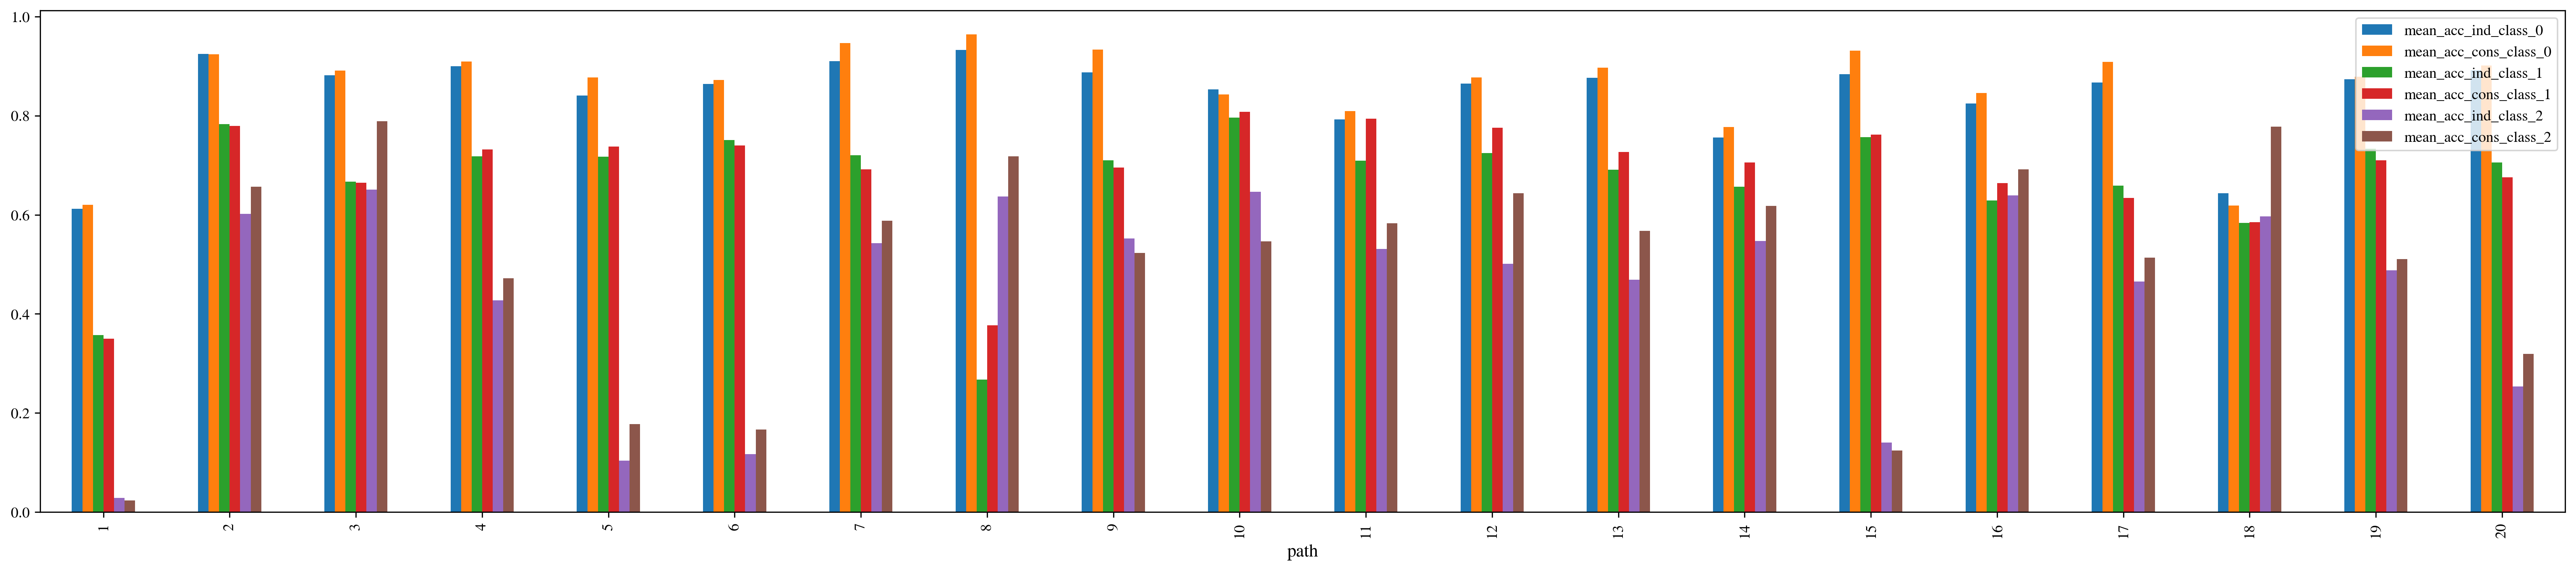

In [44]:
results_per_class_agg = pd.DataFrame()
for n_class in [0,1,2]:
    results_per_class_agg[f"mean_acc_ind_class_{n_class}"] = results_per_class.groupby(["path"])[[f"accuracy_individual_class_{n_class}"]].mean()
    results_per_class_agg[f"mean_acc_cons_class_{n_class}"] = results_per_class.groupby(["path"])[[f"accuracy_consensus_class_{n_class}"]].mean()


plt.figure(figsize=(30, 6))
results_per_class_agg.plot(kind='bar', figsize=(30, 6))
plt.show()

In [45]:
results_per_class_agg

,mean_acc_ind_class_0,mean_acc_cons_class_0,mean_acc_ind_class_1,mean_acc_cons_class_1,mean_acc_ind_class_2,mean_acc_cons_class_2
path,,,,,,
1,0.612008,0.619865,0.357337,0.349854,0.028571,0.023529
2,0.925024,0.924242,0.782821,0.779172,0.601760,0.656994
3,0.881427,0.890906,0.667165,0.664410,0.650535,0.788802
4,0.899616,0.909138,0.718370,0.731737,0.427130,0.471796
5,0.841003,0.876889,0.717649,0.737794,0.103896,0.177607
6,0.863778,0.872001,0.750612,0.739639,0.116667,0.166667
7,0.909779,0.946683,0.719857,0.691826,0.543018,0.587677
8,0.932959,0.964167,0.267546,0.377143,0.636905,0.718333
9,0.887345,0.933387,0.710272,0.695712,0.551933,0.523077


# Agreement rater vs. virtual rater

In [46]:
agreement_rater_virtual = []

for path in range(1, 21):
    for fold in range(1,6):
            real_vs_virtual = pd.DataFrame(columns=["real", "virtual"])
            real_vs_virtual["real"] = basis[(path, fold, "individual_labels")]
            real_vs_virtual["virtual"] = basis[(path, fold, "predictions")]
            agreement_nom = kd.alpha(real_vs_virtual.T.values, level_of_measurement="nominal", value_domain=[0, 1.0, 2.0])
            agreement_ord = kd.alpha(real_vs_virtual.T.values, level_of_measurement="ordinal", value_domain=[0, 1.0, 2.0])
            accuracy = accuracy_score(
                basis[(path, fold, "individual_labels")],
                basis[(path, fold, "predictions")]
            )
            dict_temp = {
                "path": path,
                "fold": fold,
                "alpha_nom": agreement_nom,
                "alpha_ord": agreement_ord,
                "accuracy": accuracy
            }
            agreement_rater_virtual.append(dict_temp)
agreement_rater_virtual = pd.DataFrame(agreement_rater_virtual)
agreement_rater_virtual_agg = agreement_rater_virtual.groupby(["path"])[["alpha_nom", "alpha_ord", "accuracy"]].mean()
agreement_rater_virtual_agg

,alpha_nom,alpha_ord,accuracy
path,,,
1,0.005435,0.000372,0.471327
2,0.710737,0.811363,0.830911
3,0.613181,0.739256,0.759894
4,0.598891,0.726656,0.763856
5,0.515294,0.620466,0.736879
6,0.586537,0.639819,0.788571
7,0.654883,0.746188,0.808970
8,0.461004,0.668593,0.710345
9,0.625201,0.723784,0.786364


In [47]:
agreement_rater_virtual_agg["samples"] = results_agg["samples"] 

In [48]:
samples = agreement_rater_virtual_agg["samples"]
norm_samples = (samples - samples.min()) / (samples.max() - samples.min())
colors = seq_cm(norm_samples)

fig, ax = plt.subplots(figsize=figsize_horizontal)
bars = agreement_rater_virtual_agg["alpha_ord"].plot(kind='bar', width=0.4, color=colors, edgecolor='black', ax=ax)

sm = cm.ScalarMappable(cmap=seq_cm, norm=plt.Normalize(vmin=samples.min(), vmax=samples.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Total Training Samples')

plt.title('Pairwise Agreement between Pathologists and their Virtual Surrogate')
plt.ylabel("Pairwise Agreement (Krippendorff's Alpha)")
plt.xlabel("Pathologist")
plt.yticks()
plt.xticks(ticks=np.arange(20), labels=[f'{i+1}' for i in range(20)], rotation=0)
plt.show()

NameError: name 'figsize_horizontal' is not defined